# Credit Card Fraud Detection - Exploratory Data Analysis

This notebook performs exploratory data analysis on credit card transactions to understand patterns in fraudulent vs normal transactions. 

## Dataset Description
- The dataset contains credit card transactions
- Features V1-V28 are principal components obtained with PCA
- 'Time' is the seconds elapsed between each transaction and the first transaction
- 'Amount' is the transaction amount
- 'Class' is the response variable (1 for fraud, 0 for normal)

In [17]:
import pandas as pd #To hand with data 
import numpy as np #To math 
import seaborn as sns #to visualization
import matplotlib.pyplot as plt # to plot the graphs
import matplotlib.gridspec as gridspec # to do the grid of plots

In [18]:
#loading the data
df_credit = pd.read_csv("../data/creditcard.csv")

In [19]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
#looking the type and searching for null values
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

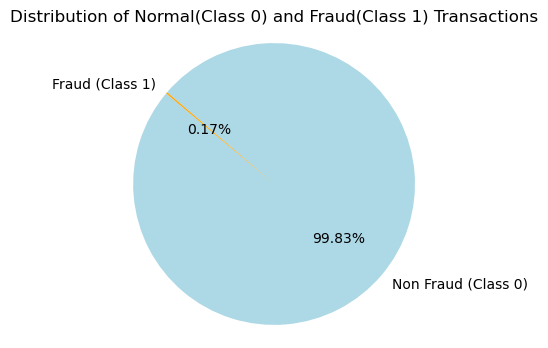

In [20]:

class_counts = df_credit["Class"].value_counts()
# Define labels and colors
labels = ['Non Fraud (Class 0)', 'Fraud (Class 1)']
colors = ['lightblue', 'orange']

# Create pie chart
plt.figure(figsize=(4, 4))
plt.pie(class_counts, labels=labels, colors=colors, autopct='%1.2f%%', startangle=140)
plt.title("Distribution of Normal(Class 0) and Fraud(Class 1) Transactions")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

In [ ]:
# Define a function to convert time in seconds to minutes and hours
def convert_time(seconds):
    minutes = seconds // 60
    hours = minutes // 60
    return minutes % 60, hours % 24

# Create empty lists to store the converted values
time_min_values = []
time_hour_values = []

# Apply the conversion function to each time value in the dataframe
for time_sec in df_credit['Time']:
    minutes, hours = convert_time(time_sec)
    time_min_values.append(minutes)
    time_hour_values.append(hours)

# Add the converted values as new columns to the DataFrame
df_credit['Time_min'] = time_min_values
df_credit['Time_hour'] = time_hour_values

In [22]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,Time_min,Time_hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.0


<Figure size 1200x500 with 0 Axes>

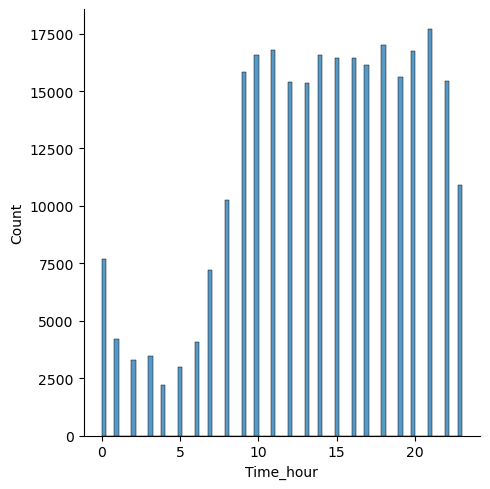

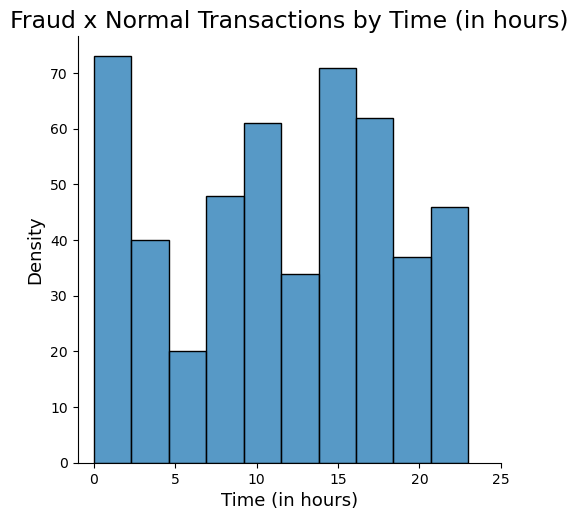

In [23]:
#Exploring the distribuition by Class types throught hours and minutes
plt.figure(figsize=(12,5))
sns.displot(df_credit[df_credit['Class'] == 0]["Time_hour"])
sns.displot(df_credit[df_credit['Class'] == 1]["Time_hour"])
plt.xlabel("Time (in hours)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title('Fraud x Normal Transactions by Time (in hours)', fontsize=17)
plt.xlim([-1,25])
plt.show()

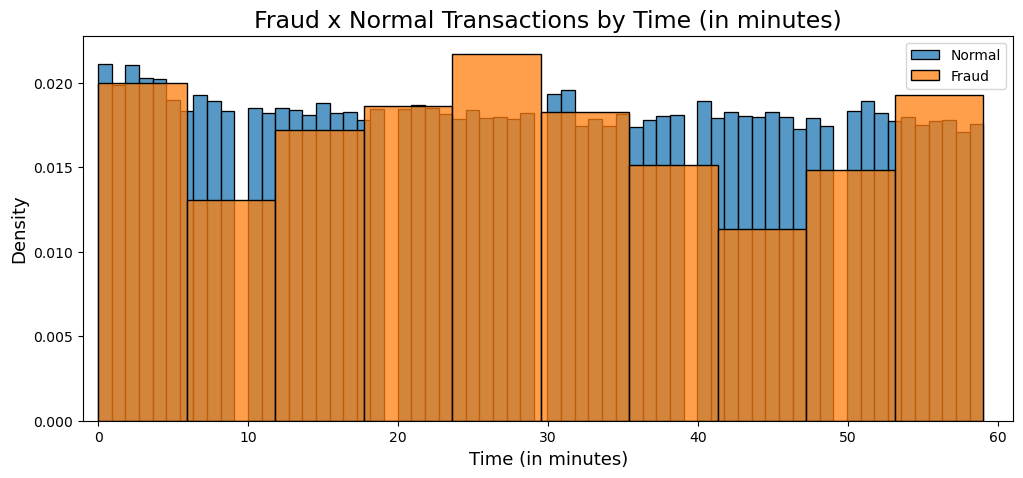

In [25]:
#Exploring the distribution by Class types through hours and minutes
plt.figure(figsize=(12,5))
sns.histplot(data=df_credit[df_credit['Class'] == 0], x="Time_min", stat="density", label="Normal")
sns.histplot(data=df_credit[df_credit['Class'] == 1], x="Time_min", stat="density", label="Fraud")
plt.xlabel("Time (in minutes)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.title('Fraud x Normal Transactions by Time (in minutes)', fontsize=17)
plt.xlim([-1,61])
plt.legend()
plt.show()

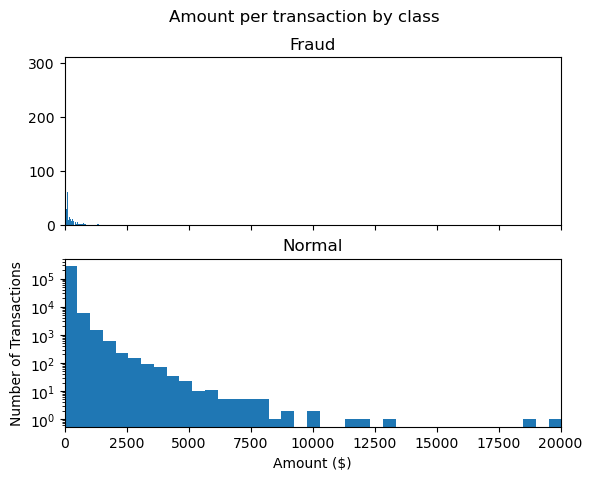

In [26]:
df_fraud = df_credit[df_credit['Class'] == 1]
df_normal = df_credit[df_credit['Class'] == 0]

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Amount per transaction by class')
bins = 50
ax1.hist(df_fraud.Amount, bins = bins)
ax1.set_title('Fraud')
ax2.hist(df_normal.Amount, bins = bins)
ax2.set_title('Normal')
plt.xlabel('Amount ($)')
plt.ylabel('Number of Transactions')
plt.xlim((0, 20000))
plt.yscale('log')
plt.show()

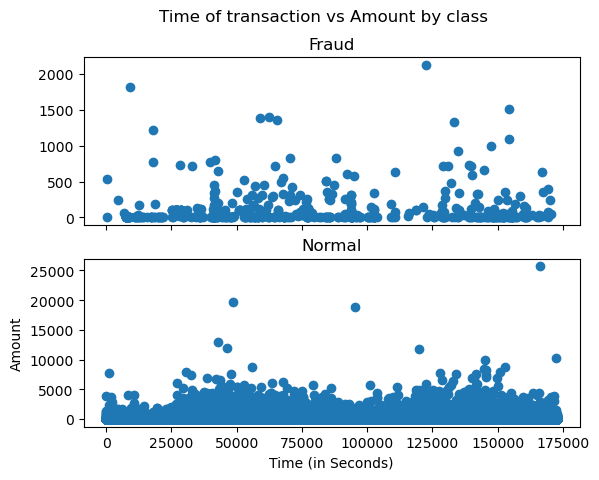

In [27]:
# We Will check Do fraudulent transactions occur more often during certain time frame ? Let us find out with a visual representation.

f, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
f.suptitle('Time of transaction vs Amount by class')
ax1.scatter(df_fraud.Time, df_fraud.Amount)
ax1.set_title('Fraud')
ax2.scatter(df_normal.Time, df_normal.Amount)
ax2.set_title('Normal')
plt.xlabel('Time (in Seconds)')
plt.ylabel('Amount')
plt.show()

In [28]:
#To describe the data of frauds and no frauds
df_fraud = df_credit[df_credit['Class'] == 1]
df_normal = df_credit[df_credit['Class'] == 0]

print("Fraud transaction statistics")
print(df_fraud["Amount"].describe())
print("\nNormal transaction statistics")
print(df_normal["Amount"].describe())

Fraud transaction statistics
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal transaction statistics
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


In [29]:
# Calculate statistics using pandas methods for better performance
fraud_stats = df_credit[df_credit['Class'] == 1]['Amount'].agg({
    'Count': 'count',
    'Total Amount': 'sum',
    'Minimum Amount': 'min',
    'Maximum Amount': 'max',
    'Average Amount': 'mean',
    'Standard Deviation': 'std',
    '25th Percentile': lambda x: x.quantile(0.25),
    'Median (50th Percentile)': 'median',
    '75th Percentile': lambda x: x.quantile(0.75)
})

normal_stats = df_credit[df_credit['Class'] == 0]['Amount'].agg({
    'Count': 'count',
    'Total Amount': 'sum',
    'Minimum Amount': 'min',
    'Maximum Amount': 'max',
    'Average Amount': 'mean',
    'Standard Deviation': 'std',
    '25th Percentile': lambda x: x.quantile(0.25),
    'Median (50th Percentile)': 'median',
    '75th Percentile': lambda x: x.quantile(0.75)
})

print("Fraud transaction statistics")
print(fraud_stats)
print("\nNormal transaction statistics")
print(normal_stats)

Fraud transaction statistics
Count                         492.000000
Total Amount                60127.970000
Minimum Amount                  0.000000
Maximum Amount               2125.870000
Average Amount                122.211321
Standard Deviation            256.683288
25th Percentile                 1.000000
Median (50th Percentile)        9.250000
75th Percentile               105.890000
Name: Amount, dtype: float64

Normal transaction statistics
Count                       2.843150e+05
Total Amount                2.510246e+07
Minimum Amount              0.000000e+00
Maximum Amount              2.569116e+04
Average Amount              8.829102e+01
Standard Deviation          2.501051e+02
25th Percentile             5.650000e+00
Median (50th Percentile)    2.200000e+01
75th Percentile             7.705000e+01
Name: Amount, dtype: float64


In [ ]:
#Feature engineering to a better visualization of the values
df_credit['Amount_log'] = np.log(df_credit.Amount + 0.01)

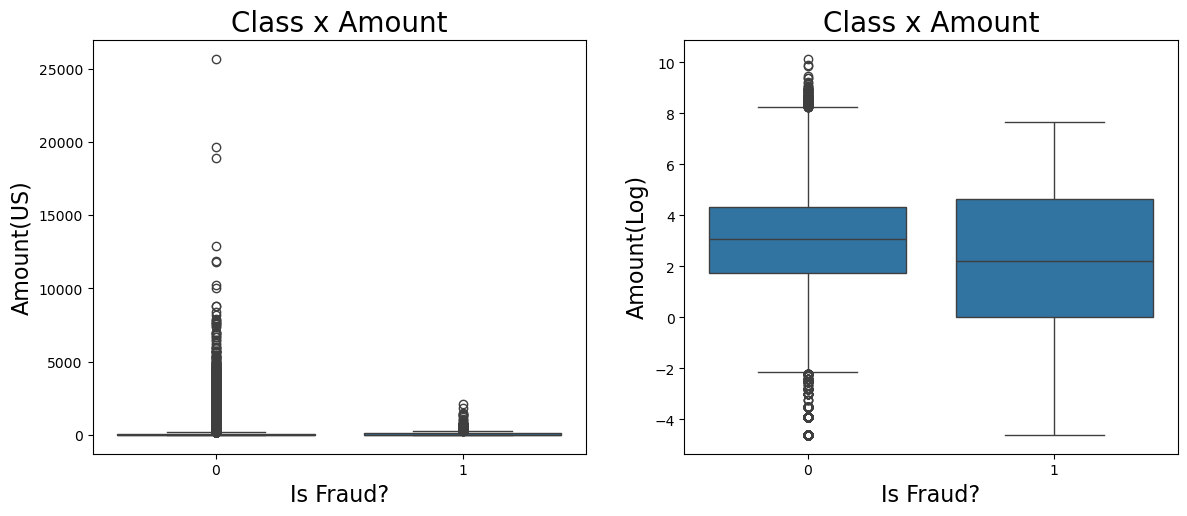

In [31]:
plt.figure(figsize=(14,6))
#I will explore the Amount by Class and see the distribuition of Amount transactions
plt.subplot(121)
ax = sns.boxplot(x ="Class",y="Amount",
                 data=df_credit)
ax.set_title("Class x Amount", fontsize=20)
ax.set_xlabel("Is Fraud?", fontsize=16)
ax.set_ylabel("Amount(US)", fontsize = 16)

plt.subplot(122)
ax1 = sns.boxplot(x ="Class",y="Amount_log", data=df_credit)
ax1.set_title("Class x Amount", fontsize = 20)
ax1.set_xlabel("Is Fraud?", fontsize = 16)
ax1.set_ylabel("Amount(Log)", fontsize = 16)

plt.subplots_adjust(hspace = 0.6, top = 0.8)

plt.show()

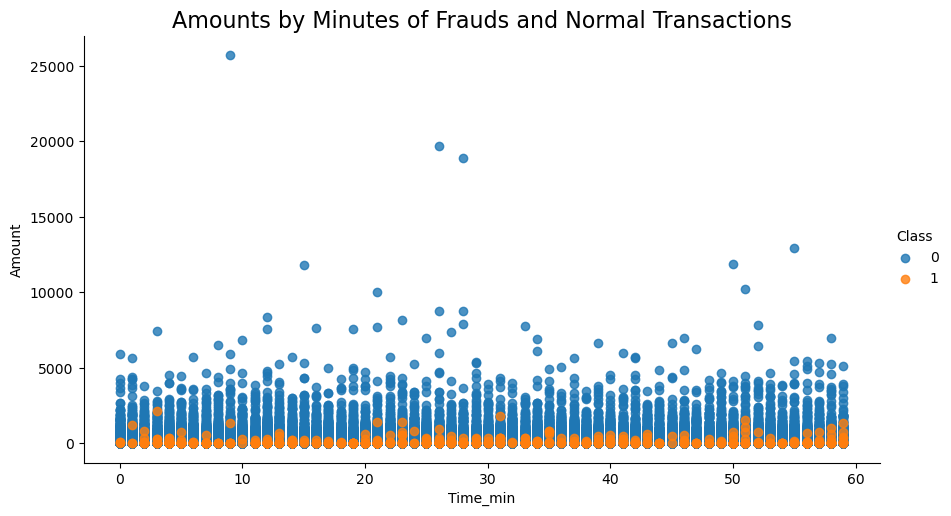

In [32]:
#Looking the Amount and time distribuition of FRAUD transactions
ax = sns.lmplot(y="Amount", x="Time_min", fit_reg=False,aspect=1.8,
                data=df_credit, hue='Class')
plt.title("Amounts by Minutes of Frauds and Normal Transactions",fontsize=16)
plt.show()

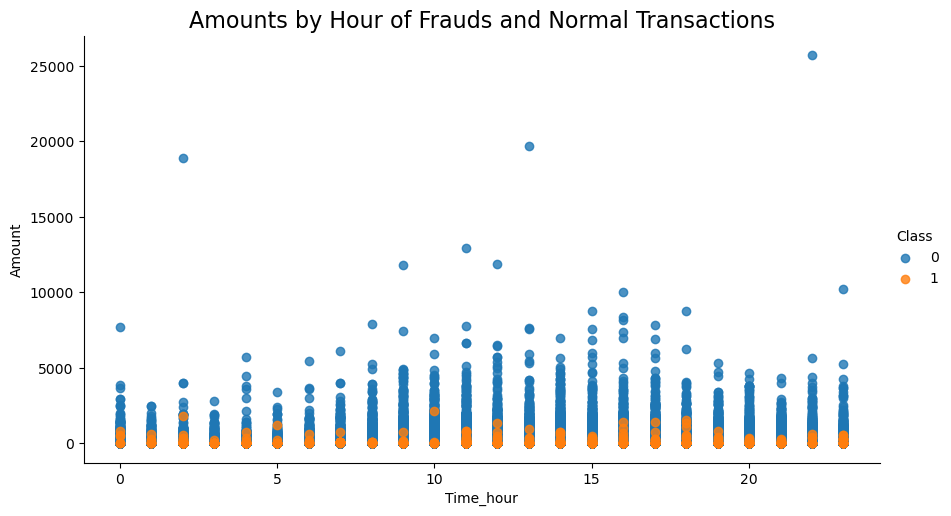

In [33]:
ax = sns.lmplot(y="Amount", x="Time_hour", fit_reg=False,aspect=1.8,
                data=df_credit, hue='Class')
plt.title("Amounts by Hour of Frauds and Normal Transactions", fontsize=16)

plt.show()

In [34]:
# Create a new column for log-transformed amount instead of overwriting
df_credit['Amount_log_transformed'] = np.log(df_credit.Amount + 0.001)

#Looking at the final df
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Time_min,Time_hour,Amount_log,Amount_log_transformed
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0,5.008166,5.008105
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0,0.993252,0.989913
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0,5.936665,5.936641
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.0,4.816322,4.816249
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.0,4.248495,4.248367


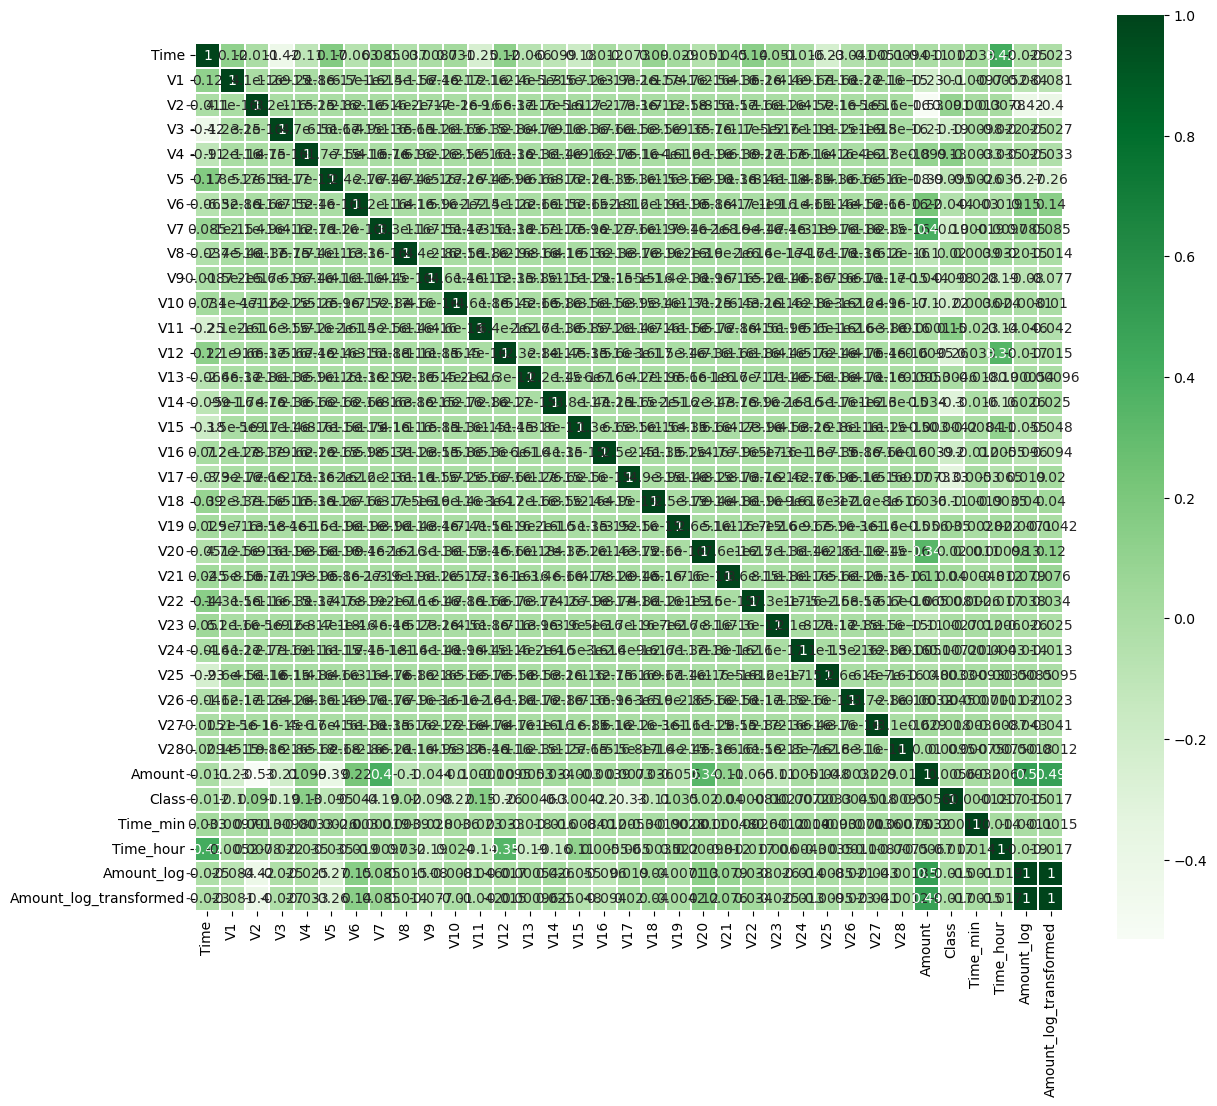

In [35]:
colormap = plt.cm.Greens

plt.figure(figsize=(14,12))

sns.heatmap(df_credit.corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap = colormap, linecolor='white', annot=True)
plt.show()

In [36]:
df_credit

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V25,V26,V27,V28,Amount,Class,Time_min,Time_hour,Amount_log,Amount_log_transformed
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0,0.0,5.008166,5.008105
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0,0.0,0.993252,0.989913
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0,0.0,5.936665,5.936641
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0,0.0,4.816322,4.816249
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0,0.0,4.248495,4.248367
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.436807,0.250034,0.943651,0.823731,0.77,0,59.0,23.0,-0.248461,-0.260067
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,59.0,23.0,3.210844,3.210481
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.265745,-0.087371,0.004455,-0.026561,67.88,0,59.0,23.0,4.217889,4.217756
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,-0.569159,0.546668,0.108821,0.104533,10.00,0,59.0,23.0,2.303585,2.302685


In [37]:
# Verification Summary
print("Dataset Verification Summary:")
print("-" * 50)

# Check data completeness
print("\n1. Data Completeness:")
print(f"Total rows: {len(df_credit)}")
print(f"Missing values:\n{df_credit.isnull().sum()}")

# Class balance
print("\n2. Class Distribution:")
class_dist = df_credit['Class'].value_counts(normalize=True)
print(f"Normal transactions: {class_dist[0]:.2%}")
print(f"Fraudulent transactions: {class_dist[1]:.2%}")

# Amount ranges
print("\n3. Amount Ranges by Class:")
for class_label in [0, 1]:
    class_name = "Normal" if class_label == 0 else "Fraudulent"
    class_data = df_credit[df_credit['Class'] == class_label]['Amount']
    print(f"\n{class_name} Transactions:")
    print(f"Min: ${class_data.min():.2f}")
    print(f"Max: ${class_data.max():.2f}")
    print(f"Mean: ${class_data.mean():.2f}")
    print(f"Median: ${class_data.median():.2f}")

# Time span
print("\n4. Time Span:")
time_range = df_credit['Time'].max() - df_credit['Time'].min()
print(f"Total time span: {time_range/3600:.1f} hours")

# Correlation with target
print("\n5. Top correlations with Class (fraud):")
correlations = df_credit.corr()['Class'].sort_values(ascending=False)
print(correlations.head())
print("\nBottom correlations with Class (fraud):")
print(correlations.tail())

Dataset Verification Summary:
--------------------------------------------------

1. Data Completeness:
Total rows: 284807
Missing values:
Time                      0
V1                        0
V2                        0
V3                        0
V4                        0
V5                        0
V6                        0
V7                        0
V8                        0
V9                        0
V10                       0
V11                       0
V12                       0
V13                       0
V14                       0
V15                       0
V16                       0
V17                       0
V18                       0
V19                       0
V20                       0
V21                       0
V22                       0
V23                       0
V24                       0
V25                       0
V26                       0
V27                       0
V28                       0
Amount                    0
Class                